In [7]:
#01Data Check
from pathlib import Path
import pandas as pd
SHEET_NAME = "Frozen_Model_Data"
EXPECTED_COUNTRIES = {
    "GBR": "United Kingdom",
    "FRA": "France",
    "DEU": "Germany",
    "USA": "United States",
    "CAN": "Canada",
    "JPN": "Japan",
    "KOR": "South Korea",
}

MAIN_INDICATORS = [
    "Population",
    "Total_GDP_PPP_USD_million",
    "GDP_per_capita_PPP_USD",
    "Road_Density_km_per_km2",
    "Railway_Stations",
    "Airports",
    "Universities",
    "Hospitals",
]

IDENTIFIER_COLUMNS = [
    "ID",
    "Country",
    "ISO3",
    "Rank_in_Country",
    "FUA_Code",
    "FUA_Name",
    "Core_City",
]

In [4]:
#3.read data
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"找不到冻结数据文件：{INPUT_FILE}")

df = pd.read_excel(
    INPUT_FILE,
    sheet_name=SHEET_NAME,
    engine="openpyxl",
)

#Check required fields
required_columns = IDENTIFIER_COLUMNS + MAIN_INDICATORS
missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "冻结工作簿缺少必要字段："
        + ", ".join(missing_columns)
    )

#check sample structure
n_cities = len(df)
n_countries = df["ISO3"].nunique()
n_unique_fua = df["FUA_Code"].nunique()
country_counts = (
    df.groupby(["ISO3", "Country"], dropna=False)
    .size()
    .rename("Number_of_Cities")
    .reset_index()
    .sort_values("ISO3")
)
duplicate_fua = df.loc[
    df["FUA_Code"].duplicated(keep=False),
    ["ID", "ISO3", "FUA_Code", "FUA_Name"],
].sort_values("FUA_Code")

In [6]:
#Convert the 8 indicators into numerical values
numeric_conversion_issues = {}
for indicator in MAIN_INDICATORS:
    original_non_missing = df[indicator].notna()

    converted = pd.to_numeric(
        df[indicator],
        errors="coerce",
    )

    conversion_failed = original_non_missing & converted.isna()

    if conversion_failed.any():
        numeric_conversion_issues[indicator] = df.loc[
            conversion_failed,
            ["FUA_Code", "FUA_Name", indicator],
        ]

    df[indicator] = converted

#Check for missing, zero, and negative values
quality_audit = pd.DataFrame({
    "Indicator": MAIN_INDICATORS,
    "N": [df[column].notna().sum() for column in MAIN_INDICATORS],
    "Missing": [df[column].isna().sum() for column in MAIN_INDICATORS],
    "Zero": [(df[column] == 0).sum() for column in MAIN_INDICATORS],
    "Negative": [(df[column] < 0).sum() for column in MAIN_INDICATORS],
    "Minimum": [df[column].min() for column in MAIN_INDICATORS],
    "Maximum": [df[column].max() for column in MAIN_INDICATORS],
})
print("Quality inspection based on eight indicators")
print(
    quality_audit.to_string(
        index=False,
        float_format=lambda value: f"{value:,.3f}",
    )
)
print()

Quality inspection based on eight indicators
                Indicator  N  Missing  Zero  Negative     Minimum        Maximum
               Population 56        0     0         0 852,382.000 36,803,277.000
Total_GDP_PPP_USD_million 56        0     0         0  43,757.107  1,841,767.000
   GDP_per_capita_PPP_USD 56        0     0         0  29,973.000    146,666.000
  Road_Density_km_per_km2 56        0     0         0       1.242         10.287
         Railway_Stations 56        0     0         0       2.000      1,202.000
                 Airports 56        0     4         0       0.000          8.000
             Universities 56        0     0         0       4.000        299.000
                Hospitals 56        0     0         0       9.000      1,303.000



In [10]:
#02descriptive diagnostics
import matplotlib.pyplot as plt
import seaborn as sns

MAIN_INDICATORS = [
    "Population",
    "Total_GDP_PPP_USD_million",
    "GDP_per_capita_PPP_USD",
    "Road_Density_km_per_km2",
    "Railway_Stations",
    "Airports",
    "Universities",
    "Hospitals",
]
SHORT_NAMES = {
    "Population": "Population",
    "Total_GDP_PPP_USD_million": "Total GDP PPP",
    "GDP_per_capita_PPP_USD": "GDP per capita PPP",
    "Road_Density_km_per_km2": "Road density",
    "Railway_Stations": "Railway stations",
    "Airports": "Airports",
    "Universities": "Universities",
    "Hospitals": "Hospitals",
}

df = pd.read_excel(
    INPUT_FILE,
    sheet_name=SHEET_NAME,
    engine="openpyxl",
)
for indicator in MAIN_INDICATORS:
    df[indicator] = pd.to_numeric(
        df[indicator],
        errors="raise",
    )

#descriptive statistic
descriptive_rows = []
for indicator in MAIN_INDICATORS:
    series = df[indicator].dropna()

    q1 = series.quantile(0.25)
    median = series.quantile(0.50)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    iqr_flag_count = (
        (series < lower_fence)
        | (series > upper_fence)
    ).sum()

    mean = series.mean()
    standard_deviation = series.std(ddof=1)

    descriptive_rows.append({
        "Indicator": indicator,
        "Short_Name": SHORT_NAMES[indicator],
        "N": series.count(),
        "Missing": series.isna().sum(),
        "Zero": series.eq(0).sum(),
        "Minimum": series.min(),
        "Q1": q1,
        "Median": median,
        "Mean": mean,
        "Q3": q3,
        "Maximum": series.max(),
        "Standard_Deviation": standard_deviation,
        "Coefficient_of_Variation": (
            standard_deviation / mean
            if mean != 0
            else float("nan")
        ),
        "Skewness": series.skew(),
        "Excess_Kurtosis": series.kurt(),
        "IQR_Lower_Fence": lower_fence,
        "IQR_Upper_Fence": upper_fence,
        "IQR_Flag_Count": int(iqr_flag_count),
    })

descriptive_stats = pd.DataFrame(descriptive_rows)

In [11]:
print(descriptive_stats)

                   Indicator          Short_Name   N  Missing  Zero  \
0                 Population          Population  56        0     0   
1  Total_GDP_PPP_USD_million       Total GDP PPP  56        0     0   
2     GDP_per_capita_PPP_USD  GDP per capita PPP  56        0     0   
3    Road_Density_km_per_km2        Road density  56        0     0   
4           Railway_Stations    Railway stations  56        0     0   
5                   Airports            Airports  56        0     4   
6               Universities        Universities  56        0     0   
7                  Hospitals           Hospitals  56        0     0   

         Minimum            Q1        Median          Mean            Q3  \
0  852382.000000  1.521374e+06  2.369108e+06  5.159692e+06  6.584246e+06   
1   43757.107176  6.912200e+04  1.274850e+05  3.267611e+05  4.279676e+05   
2   29973.000000  4.143059e+04  5.397723e+04  5.843935e+04  6.865450e+04   
3       1.242267  2.721440e+00  3.671531e+00  3.944477e+

In [36]:
#main descriptive statistic
display_columns = [
    "Short_Name",
    "N",
    "Zero",
    "Minimum",
    "Median",
    "Mean",
    "Maximum",
    "Standard_Deviation",
    "Skewness",
    "Excess_Kurtosis",
    "IQR_Flag_Count",
]

table3 = (
    descriptive_stats[display_columns]
    .rename(columns={
        "Short_Name": "Indicator",
        "Standard_Deviation": "SD",
        "Excess_Kurtosis": "Kurtosis",
        "IQR_Flag_Count": "Outliers",
    })
)
table3.to_excel(
    "Table_3_2_Descriptive_Statistics.xlsx",
    index=False,
    sheet_name="Table_3_2",
)

print("Table saved.")

Table saved.


In [14]:
display(table3)

,Indicator,N,Zero,Minimum,Median,Mean,Maximum,SD,Skewness,Kurtosis,Outliers
0,Population,56,0,852382.000000,2.369108e+06,5.159692e+06,3.680328e+07,6.772705e+06,2.759081,8.879135,5
1,Total GDP PPP,56,0,43757.107176,1.274850e+05,3.267611e+05,1.841767e+06,4.287083e+05,2.110736,4.221123,6
2,GDP per capita PPP,56,0,29973.000000,5.397723e+04,5.843935e+04,1.466660e+05,2.047451e+04,1.681844,4.936350,1
3,Road density,56,0,1.242267,3.671531e+00,3.944477e+00,1.028699e+01,1.967154e+00,1.180974,1.844414,3
4,Railway stations,56,0,2.000000,5.950000e+01,1.285357e+02,1.202000e+03,2.184958e+02,3.328625,12.493589,6
5,Airports,56,4,0.000000,1.000000e+00,1.785714e+00,8.000000e+00,1.626086e+00,2.254232,6.146416,2
6,Universities,56,0,4.000000,2.300000e+01,4.262500e+01,2.990000e+02,5.331504e+01,2.829762,9.781573,8
7,Hospitals,56,0,9.000000,5.750000e+01,1.230893e+02,1.303000e+03,2.122198e+02,4.236576,20.143633,5


In [16]:
#IQR rules
flagged_rows = []

for indicator in MAIN_INDICATORS:
    series = df[indicator]

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    mask = (
        (series < lower_fence)
        | (series > upper_fence)
    )

    indicator_flags = df.loc[
        mask,
        [
            "ISO3",
            "FUA_Code",
            "FUA_Name",
            indicator,
        ],
    ].copy()

    indicator_flags = indicator_flags.rename(
        columns={indicator: "Observed_Value"}
    )

    indicator_flags["Indicator"] = indicator
    indicator_flags["Lower_Fence"] = lower_fence
    indicator_flags["Upper_Fence"] = upper_fence
    indicator_flags["Flag_Type"] = "IQR diagnostic only"

    flagged_rows.append(indicator_flags)

flagged_observations = pd.concat(
    flagged_rows,
    ignore_index=True,
)

flagged_observations = flagged_observations[
    [
        "Indicator",
        "ISO3",
        "FUA_Code",
        "FUA_Name",
        "Observed_Value",
        "Lower_Fence",
        "Upper_Fence",
        "Flag_Type",
    ]
]

print("Flag IQR Rules")

if flagged_observations.empty:
    print("没有观察被IQR规则标记。")
else:
    print(
        flagged_observations.to_string(
            index=False,
            float_format=lambda value: f"{value:,.3f}",
        )
    )

print()

Flag IQR Rules
                Indicator ISO3 FUA_Code                FUA_Name  Observed_Value    Lower_Fence    Upper_Fence           Flag_Type
               Population  USA   USA01F      New York (Greater)  20,458,991.000 -6,072,934.625 14,178,554.375 IQR diagnostic only
               Population  USA   USA02F   Los Angeles (Greater)  17,614,692.000 -6,072,934.625 14,178,554.375 IQR diagnostic only
               Population  JPN   JPN01F                   Tokyo  36,803,277.000 -6,072,934.625 14,178,554.375 IQR diagnostic only
               Population  JPN   JPN02F                   Osaka  17,006,838.000 -6,072,934.625 14,178,554.375 IQR diagnostic only
               Population  KOR   KOR01F                   Seoul  24,352,950.000 -6,072,934.625 14,178,554.375 IQR diagnostic only
Total_GDP_PPP_USD_million  GBR   UK001F                  London     973,152.000   -469,146.335    966,235.892 IQR diagnostic only
Total_GDP_PPP_USD_million  FRA   FR001F                   Paris   1,094,374

In [21]:
#03log transformations
import numpy as np
LOG_INDICATORS = [
    "Population",
    "Total_GDP_PPP_USD_million",
    "GDP_per_capita_PPP_USD",
    "Road_Density_km_per_km2",
]

LOG1P_INDICATORS = [
    "Railway_Stations",
    "Airports",
    "Universities",
    "Hospitals",
]
MAIN_INDICATORS = LOG_INDICATORS + LOG1P_INDICATORS
SHORT_NAMES = {
    "Population": "Population",
    "Total_GDP_PPP_USD_million": "Total GDP PPP",
    "GDP_per_capita_PPP_USD": "GDP per capita PPP",
    "Road_Density_km_per_km2": "Road density",
    "Railway_Stations": "Railway stations",
    "Airports": "Airports",
    "Universities": "Universities",
    "Hospitals": "Hospitals",
}

df = pd.read_excel(
    INPUT_FILE,
    sheet_name=SHEET_NAME,
    engine="openpyxl",
)
for indicator in MAIN_INDICATORS:
    df[indicator] = pd.to_numeric(
        df[indicator],
        errors="raise",
    )


transformation_records = []

for indicator in LOG_INDICATORS:
    transformed_column = f"ln_{indicator}"

    df[transformed_column] = np.log(
        df[indicator]
    )

    transformation_records.append({
        "Indicator": indicator,
        "Short_Name": SHORT_NAMES[indicator],
        "Transformation": "ln(x)",
        "Transformed_Column": transformed_column,
        "Reason": (
            "Strictly positive continuous/scale variable"
        ),
    })


for indicator in LOG1P_INDICATORS:
    transformed_column = f"ln1p_{indicator}"

    df[transformed_column] = np.log1p(
        df[indicator]
    )

    transformation_records.append({
        "Indicator": indicator,
        "Short_Name": SHORT_NAMES[indicator],
        "Transformation": "ln(1+x)",
        "Transformed_Column": transformed_column,
        "Reason": (
            "Non-negative count variable; preserves zeros"
        ),
    })


transformation_rules = pd.DataFrame(
    transformation_records
)


transformed_columns = (
    transformation_rules["Transformed_Column"].tolist()
)

invalid_counts = {}

for column in transformed_columns:
    invalid_mask = (
        df[column].isna()
        | np.isinf(df[column])
    )

    invalid_counts[column] = int(
        invalid_mask.sum()
    )

print("Validity check of conversion results")
for column, invalid_count in invalid_counts.items():
    status = "PASS" if invalid_count == 0 else "REVIEW"

    print(
        f"{column:45s} "
        f"invalid count={invalid_count}: {status}"
    )

print()

if any(count > 0 for count in invalid_counts.values()):
    raise ValueError(
        "转换后出现NaN或无穷值，停止分析。"
    )

Validity check of conversion results
ln_Population                                 invalid count=0: PASS
ln_Total_GDP_PPP_USD_million                  invalid count=0: PASS
ln_GDP_per_capita_PPP_USD                     invalid count=0: PASS
ln_Road_Density_km_per_km2                    invalid count=0: PASS
ln1p_Railway_Stations                         invalid count=0: PASS
ln1p_Airports                                 invalid count=0: PASS
ln1p_Universities                             invalid count=0: PASS
ln1p_Hospitals                                invalid count=0: PASS



In [22]:
# Compare skewness before and after transformation
comparison_rows = []

for _, rule in transformation_rules.iterrows():
    original_column = rule["Indicator"]
    transformed_column = rule["Transformed_Column"]

    original_skewness = df[original_column].skew()
    transformed_skewness = df[transformed_column].skew()

    comparison_rows.append({
        "Indicator": rule["Short_Name"],
        "Transformation": rule["Transformation"],
        "Original_Skewness": original_skewness,
        "Transformed_Skewness": transformed_skewness,
        "Absolute_Skewness_Reduction": (
            abs(original_skewness)
            - abs(transformed_skewness)
        ),
    })

skewness_comparison = pd.DataFrame(comparison_rows)

display(
    skewness_comparison.round(3)
)

,Indicator,Transformation,Original_Skewness,Transformed_Skewness,Absolute_Skewness_Reduction
0,Population,ln(x),2.759,0.804,1.955
1,Total GDP PPP,ln(x),2.111,0.631,1.480
2,GDP per capita PPP,ln(x),1.682,0.526,1.156
3,Road density,ln(x),1.181,-0.276,0.905
4,Railway stations,ln(1+x),3.329,-0.065,3.263
5,Airports,ln(1+x),2.254,0.651,1.603
6,Universities,ln(1+x),2.830,0.434,2.396
7,Hospitals,ln(1+x),4.237,0.660,3.577


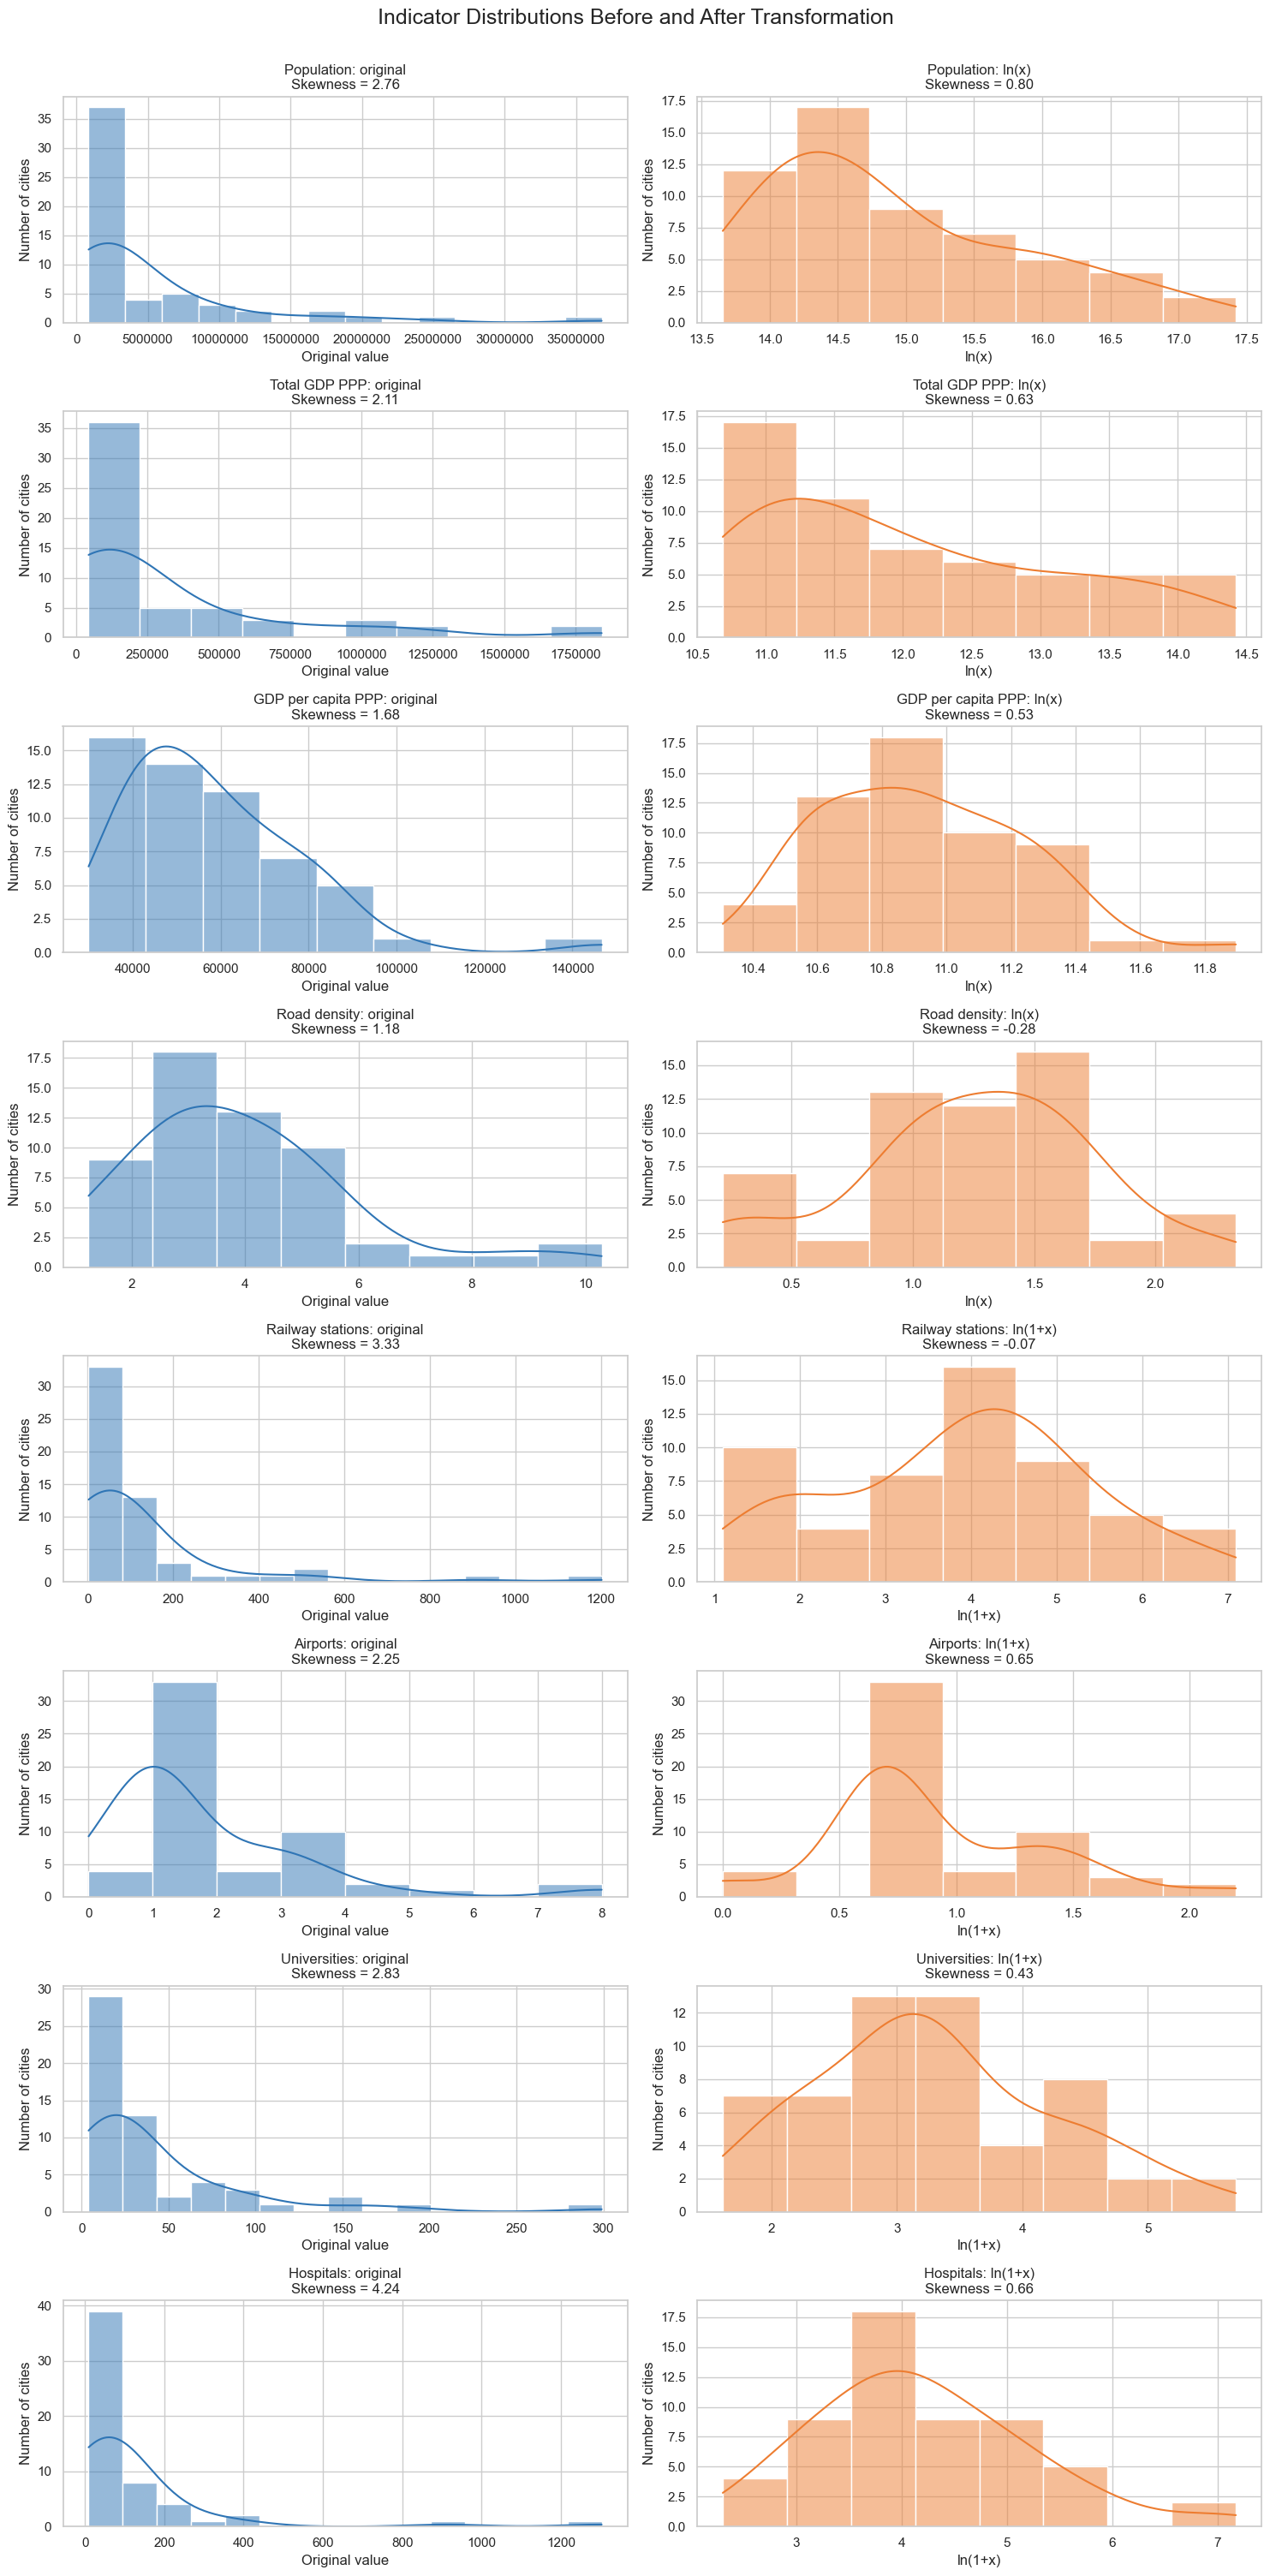

In [27]:
#Distribution plots before and after the transformation
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    nrows=8,
    ncols=2,
    figsize=(15, 30),
)

for row_number, rule in transformation_rules.iterrows():
    original_column = rule["Indicator"]
    transformed_column = rule["Transformed_Column"]
    short_name = rule["Short_Name"]

    original_axis = axes[row_number, 0]
    transformed_axis = axes[row_number, 1]

    sns.histplot(
        data=df,
        x=original_column,
        bins="auto",
        kde=True,
        color="#2F75B5",
        edgecolor="white",
        ax=original_axis,
    )

    original_axis.set_title(
        f"{short_name}: original\n"
        f"Skewness = "
        f"{df[original_column].skew():.2f}"
    )

    original_axis.set_xlabel("Original value")
    original_axis.set_ylabel("Number of cities")
    original_axis.ticklabel_format(
        style="plain",
        axis="x",
    )

    sns.histplot(
        data=df,
        x=transformed_column,
        bins="auto",
        kde=True,
        color="#ED7D31",
        edgecolor="white",
        ax=transformed_axis,
    )

    transformed_axis.set_title(
        f"{short_name}: {rule['Transformation']}\n"
        f"Skewness = "
        f"{df[transformed_column].skew():.2f}"
    )

    transformed_axis.set_xlabel(
        rule["Transformation"]
    )

    transformed_axis.set_ylabel(
        "Number of cities"
    )


fig.suptitle(
    "Indicator Distributions Before and After Transformation",
    fontsize=18,
    y=1.002,
)

fig.tight_layout()

DISTRIBUTION_FIGURE = (
    OUTPUT_DIR
    / "step_01_03_before_after_distributions.png"
)
fig.savefig(
    DISTRIBUTION_FIGURE,
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

In [28]:
png_file = OUTPUT_DIR / "Figure_3_1.png"
pdf_file = OUTPUT_DIR / "Figure_3_1.pdf"

fig.savefig(png_file, dpi=300, bbox_inches="tight")
fig.savefig(pdf_file, bbox_inches="tight")

print("Saved PNG to:", png_file.resolve())
print("Saved PDF to:", pdf_file.resolve())

Saved PNG to: /Users/cc-hoa/Desktop/毕业论文代码/results/Figure_3_1.png
Saved PDF to: /Users/cc-hoa/Desktop/毕业论文代码/results/Figure_3_1.pdf


In [30]:
#04z standardisation
#name
TRANSFORMED_INDICATORS = {
    "Population": "ln_Population",

    "Total GDP PPP":
        "ln_Total_GDP_PPP_USD_million",

    "GDP per capita PPP":
        "ln_GDP_per_capita_PPP_USD",

    "Road density":
        "ln_Road_Density_km_per_km2",

    "Railway stations":
        "ln1p_Railway_Stations",

    "Airports":
        "ln1p_Airports",

    "Universities":
        "ln1p_Universities",

    "Hospitals":
        "ln1p_Hospitals",
}

#name of z columns
Z_COLUMNS = {
    "Population": "z_Population",

    "Total GDP PPP":
        "z_Total_GDP_PPP",

    "GDP per capita PPP":
        "z_GDP_per_capita_PPP",

    "Road density":
        "z_Road_Density",

    "Railway stations":
        "z_Railway_Stations",

    "Airports":
        "z_Airports",

    "Universities":
        "z_Universities",

    "Hospitals":
        "z_Hospitals",
}

In [31]:
#check before z standardisation
for transformed_column in TRANSFORMED_INDICATORS.values():

    series = df[transformed_column]

    if series.isna().any():
        raise ValueError(
            f"{transformed_column} contains missing values."
        )

    if np.isinf(series).any():
        raise ValueError(
            f"{transformed_column} contains infinite values."
        )

    if np.isclose(series.std(ddof=1),0):
        raise ValueError(
            f"{transformed_column} has zero variance."
        )

print("All transformed variables passed quality checks.")

All transformed variables passed quality checks.


In [32]:
#calculate z standardisation
standardisation_records = []

for short_name, transformed_column in (
    TRANSFORMED_INDICATORS.items()
):
    z_column = Z_COLUMNS[short_name]

    series = df[transformed_column]

    transformed_mean = series.mean()
    transformed_sd = series.std(ddof=1)

    df[z_column] = (
        series - transformed_mean
    ) / transformed_sd

    standardisation_records.append({
        "Short_Name": short_name,
        "Transformed_Column": transformed_column,
        "Z_Column": z_column,
        "Transformed_Mean": transformed_mean,
        "Transformed_Sample_SD": transformed_sd,
        "Formula": (
            f"({transformed_column} - mean) "
            f"/ sample SD"
        ),
    })


standardisation_parameters = pd.DataFrame(
    standardisation_records
)

In [33]:
validation_rows = []
for short_name, z_column in Z_COLUMNS.items():

    z = df[z_column]

    mean_ok = np.isclose(
        z.mean(),
        0,
        atol=1e-10,
    )

    sd_ok = np.isclose(
        z.std(ddof=1),
        1,
        atol=1e-10,
    )

    validation_rows.append({
        "Variable": short_name,
        "Mean": z.mean(),
        "SD": z.std(ddof=1),
        "PASS": mean_ok and sd_ok,
    })

validation = pd.DataFrame(validation_rows)

if not validation["PASS"].all():
    raise ValueError(
        "Z-score validation failed."
    )

print("All Z-score variables passed validation.")

All Z-score variables passed validation.


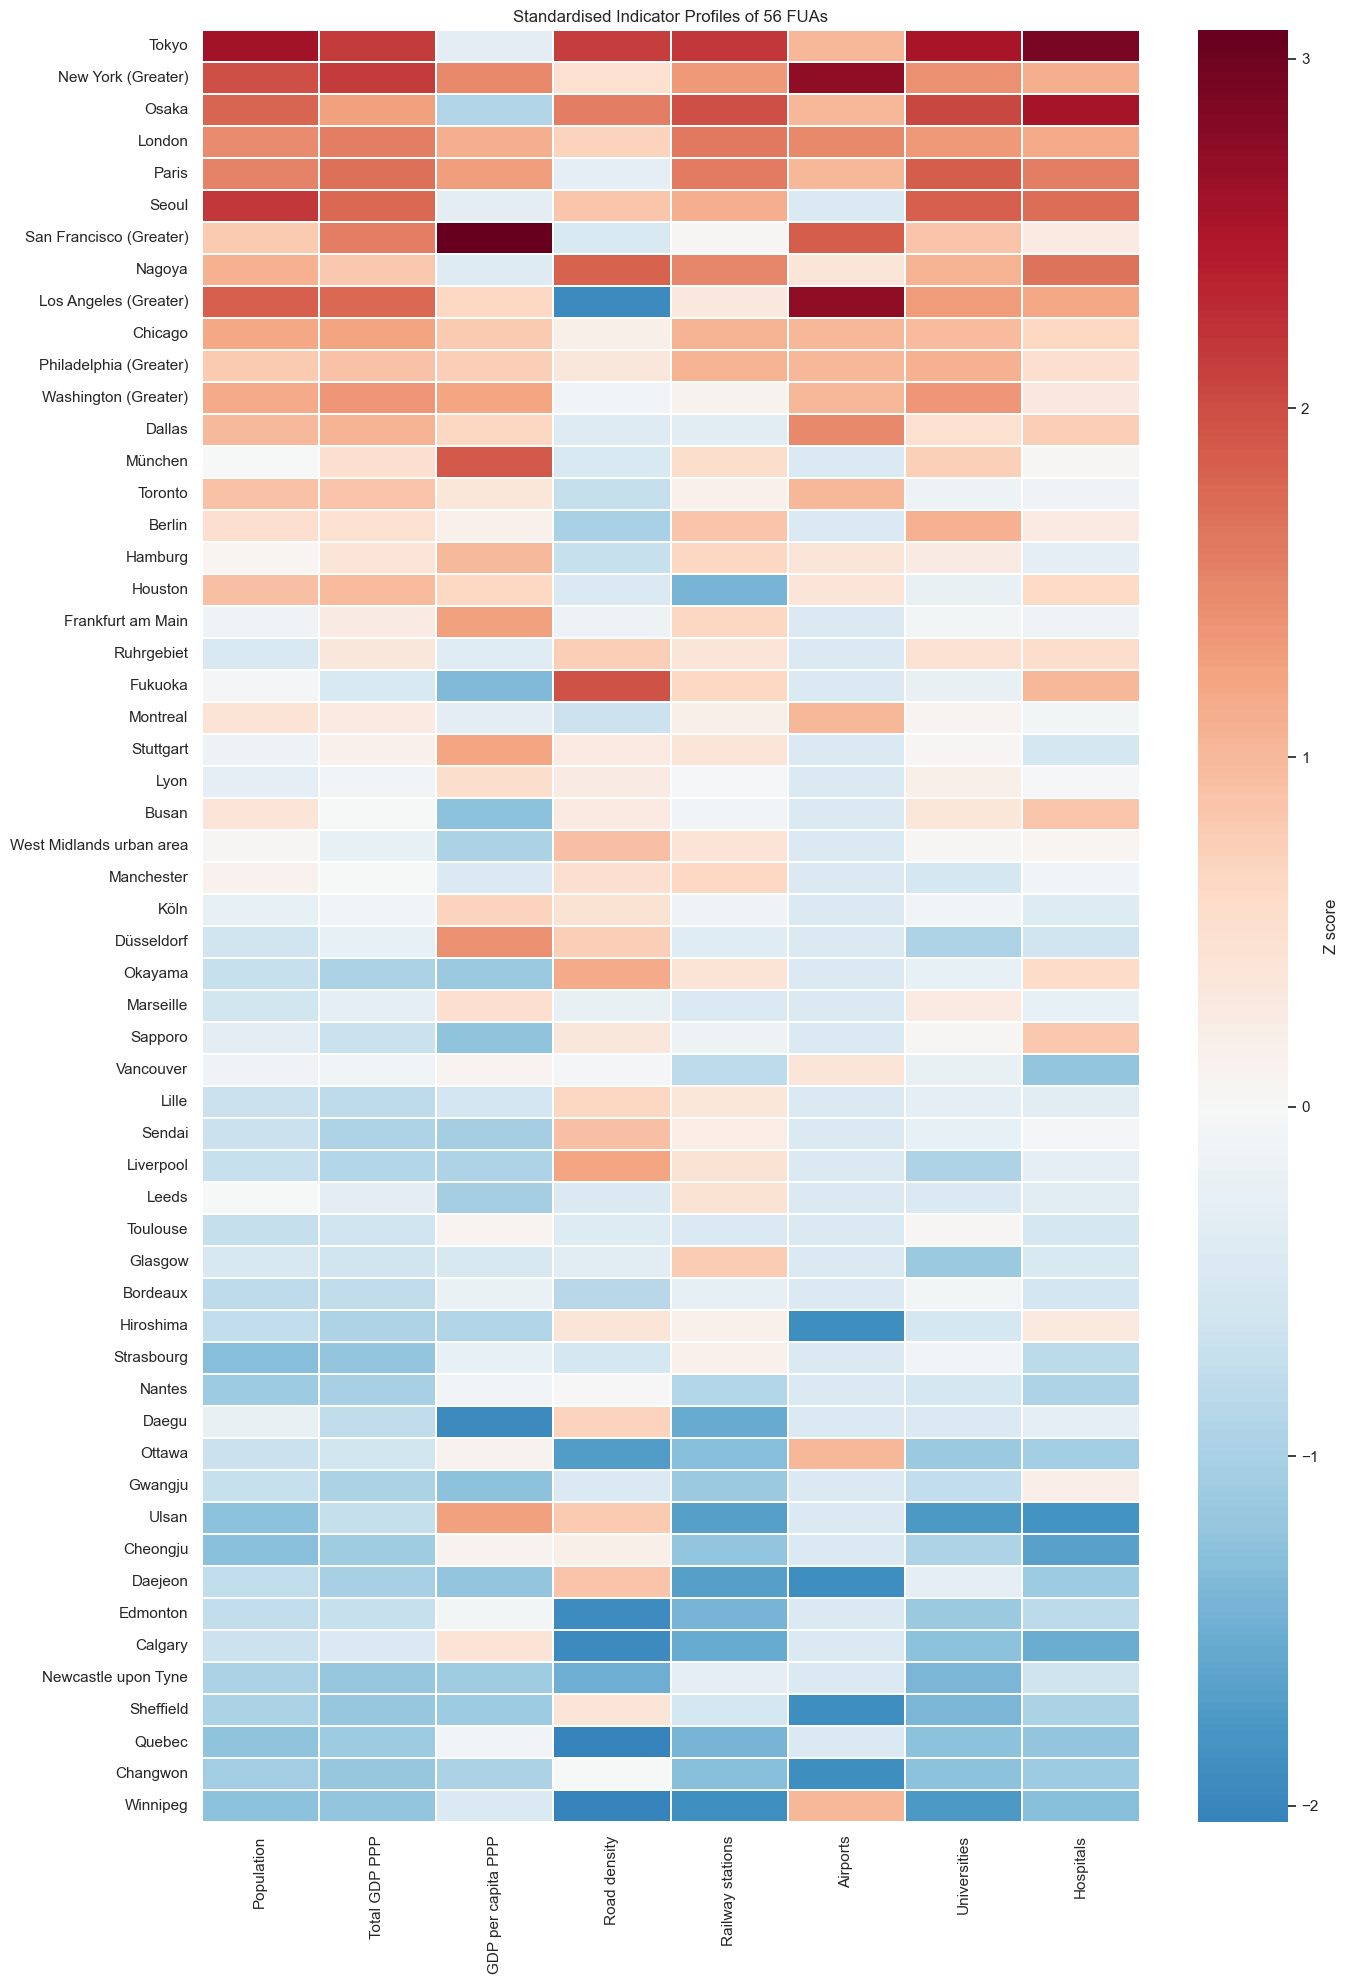

Z-score standardisation completed.
Heatmap: /Users/cc-hoa/Desktop/毕业论文代码/results/step_01_04_standardised_indicator_heatmap.png
Dimension scores and UHI have not yet been calculated.


In [34]:
#z standardisation plot
# Draw a heatmap of standardised indicator profiles
heatmap_data = (
    df.set_index("FUA_Name")[
        list(Z_COLUMNS.values())
    ]
    .rename(columns={
        value: key
        for key, value in Z_COLUMNS.items()
    })
)

# Temporary ordering for visualisation only
heatmap_order = (
    heatmap_data.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

heatmap_data = heatmap_data.loc[heatmap_order]

fig, axis = plt.subplots(figsize=(14, 20))

sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",
    center=0,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Z score"},
    ax=axis,
)

axis.set_title("Standardised Indicator Profiles of 56 FUAs")
axis.set_xlabel("")
axis.set_ylabel("")

fig.tight_layout()

HEATMAP_FILE = (
    OUTPUT_DIR
    / "step_01_04_standardised_indicator_heatmap.png"
)

fig.savefig(
    HEATMAP_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("Z-score standardisation completed.")
print("Heatmap:", HEATMAP_FILE.resolve())
print("Dimension scores and UHI have not yet been calculated.")

In [35]:
OUTPUT_FILE = (
    OUTPUT_DIR
    / "step_01_04_z_standardised_data.xlsx"
)

df.to_excel(
    OUTPUT_FILE,
    index=False,
    sheet_name="Standardised_Data",
)

print("Saved to:")
print(OUTPUT_FILE.resolve())

Saved to:
/Users/cc-hoa/Desktop/毕业论文代码/results/step_01_04_z_standardised_data.xlsx
